In [1]:
import pandas as pd
import shutil
import os
import kagglehub
"""
pip install kagglehub[pandas-datasets] to download dataset
""" 

os.makedirs('gtrsb_dataset', exist_ok=True)
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# move the dataset to current project directory
target_path = './gtrsb_dataset'
if not os.path.exists(os.path.join(target_path, 'Train.csv')):
    # Copy contents from downloaded path to target path
    if os.path.exists(target_path):
        shutil.rmtree(target_path)
    shutil.copytree(dataset_path, target_path)
    print(f"Dataset copied to: {target_path}")

# Load the dataset as a pandas DataFrame
df = pd.read_csv(os.path.join(target_path, 'Train.csv'))
print(f"Dataset loaded successfully with {len(df)} rows")
print(df.head())

C:\Users\roger\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\roger\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1
Dataset loaded successfully with 39209 rows
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


In [2]:
import pandas as pd
import cv2
import numpy as np
from PIL import Image
import os
from tqdm import tqdm

def crop_to_roi(image_path, x1, y1, x2, y2):
    """
    Crop image to the region of interest defined by bounding box coordinates.
    
    Args:
        image_path: Path to the image file
        x1, y1: Top-left corner coordinates
        x2, y2: Bottom-right corner coordinates
    
    Returns:
        Cropped image as numpy array
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Crop the image to ROI
    cropped = img[y1:y2, x1:x2]
    return cropped

def preprocess_dataset(df, dataset_path, output_path, target_size=(32, 32)):
    """
    Preprocess all images in the dataset by cropping to ROI.
    
    Args:
        df: DataFrame containing image info and bounding boxes
        dataset_path: Path to the dataset folder
        output_path: Path to save cropped images
        target_size: Resize cropped images to this size (width, height)
    """
    os.makedirs(output_path, exist_ok=True)
    
    cropped_images = []
    labels = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing images"):
        # Adjust these column names based on your CSV structure
        # Common names: 'Path', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId'
        img_path = os.path.join(dataset_path, row['Path'])
        
        # Get bounding box coordinates
        x1 = int(row['Roi.X1'])
        y1 = int(row['Roi.Y1'])
        x2 = int(row['Roi.X2'])
        y2 = int(row['Roi.Y2'])
        class_id = row['ClassId']
        
        # Crop the image
        cropped = crop_to_roi(img_path, x1, y1, x2, y2)
        
        if cropped is not None and cropped.size > 0:
            # Resize to standard size
            cropped_resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_AREA)
            
            cropped_images.append(cropped_resized)
            labels.append(class_id)
            
            # Optionally save individual cropped images
            # output_file = os.path.join(output_path, f"cropped_{idx}.png")
            # cv2.imwrite(output_file, cropped_resized)
    
    return np.array(cropped_images), np.array(labels)

# Load the dataset
target_path = './gtrsb_dataset'
df = pd.read_csv(os.path.join(target_path, 'Train.csv'))

print("DataFrame columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Preprocess and crop all images
output_path = './gtrsb_dataset/cropped_train'
cropped_images, labels = preprocess_dataset(
    df, 
    target_path, 
    output_path,
    target_size=(48, 48)  # Adjust size as needed
)

print(f"\nProcessed {len(cropped_images)} images")
print(f"Image shape: {cropped_images[0].shape}")
print(f"Labels shape: {labels.shape}")

# Save preprocessed data
np.save(os.path.join(output_path, 'cropped_images.npy'), cropped_images)
np.save(os.path.join(output_path, 'labels.npy'), labels)
print(f"\nSaved preprocessed data to {output_path}")

DataFrame columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First few rows:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


Processing images: 100%|██████████| 39209/39209 [04:38<00:00, 141.02it/s]



Processed 39209 images
Image shape: (48, 48, 3)
Labels shape: (39209,)

Saved preprocessed data to ./gtrsb_dataset/cropped_train


Generating before/after comparison...



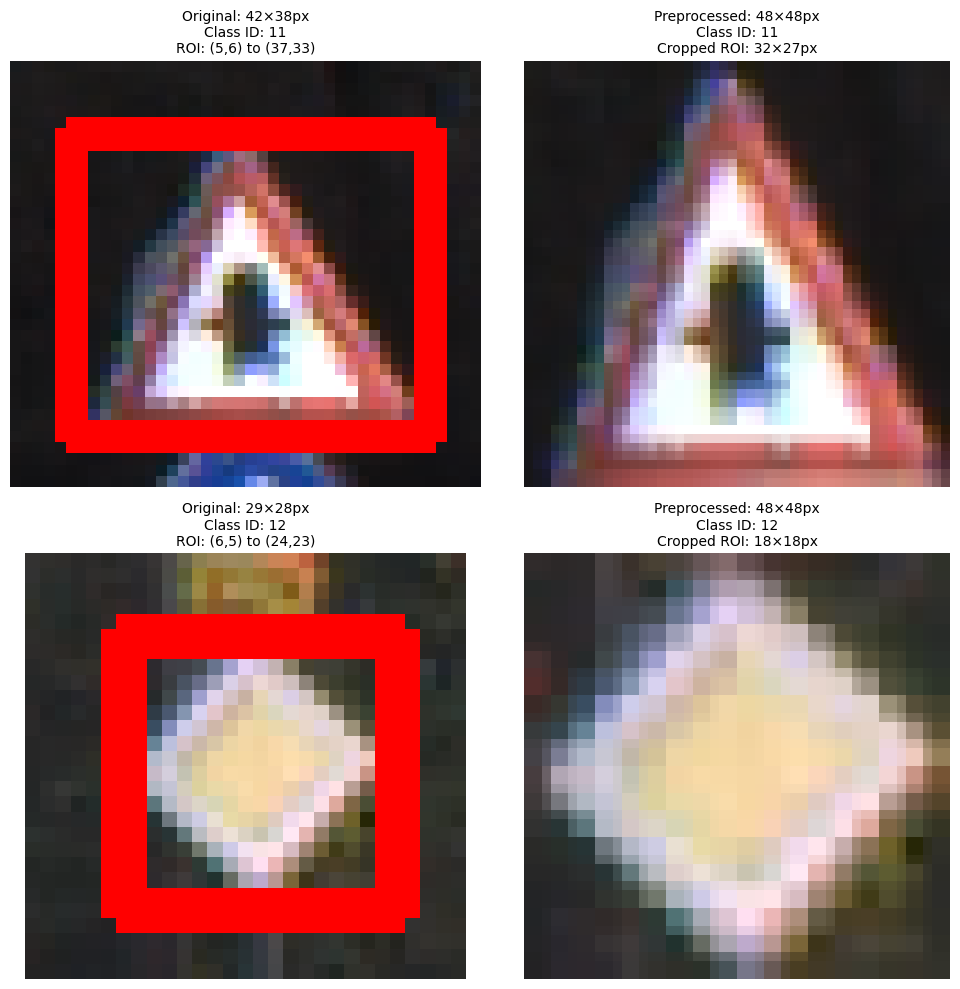

Comparison saved to: ./gtrsb_dataset/preprocessing_comparison.png


In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def visualize_preprocessing(df, dataset_path, num_samples=2, target_size=(48, 48)):
    """
    Visualize before and after preprocessing for comparison.
    
    Args:
        df: DataFrame with image info
        dataset_path: Root path of dataset
        num_samples: Number of image pairs to show
        target_size: Target size for cropped images
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    
    # Handle case where num_samples = 1
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        # Get random sample
        idx = np.random.randint(0, len(df))
        row = df.iloc[idx]
        
        # Load original image
        img_path = os.path.join(dataset_path, row['Path'])
        original = cv2.imread(img_path)
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Get bounding box
        x1, y1 = int(row['Roi.X1']), int(row['Roi.Y1'])
        x2, y2 = int(row['Roi.X2']), int(row['Roi.Y2'])
        class_id = row['ClassId']
        
        # Create copy with bounding box drawn
        original_with_box = original_rgb.copy()
        cv2.rectangle(original_with_box, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        # Crop and resize
        cropped = original[y1:y2, x1:x2]
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        cropped_resized = cv2.resize(cropped_rgb, target_size, interpolation=cv2.INTER_AREA)
        
        # Plot original with bounding box
        axes[i, 0].imshow(original_with_box)
        axes[i, 0].set_title(f'Original: {original_rgb.shape[1]}×{original_rgb.shape[0]}px\n'
                            f'Class ID: {class_id}\n'
                            f'ROI: ({x1},{y1}) to ({x2},{y2})', fontsize=10)
        axes[i, 0].axis('off')
        
        # Plot cropped and resized
        axes[i, 1].imshow(cropped_resized)
        axes[i, 1].set_title(f'Preprocessed: {target_size[0]}×{target_size[1]}px\n'
                            f'Class ID: {class_id}\n'
                            f'Cropped ROI: {x2-x1}×{y2-y1}px', fontsize=10)
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('./gtrsb_dataset/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Comparison saved to: ./gtrsb_dataset/preprocessing_comparison.png")

# Visualize the preprocessing
target_path = './gtrsb_dataset'
df = pd.read_csv(os.path.join(target_path, 'Train.csv'))

print("Generating before/after comparison...\n")
visualize_preprocessing(df, target_path, num_samples=2, target_size=(48, 48))

DATA AUGMENTATION FOR CLASS BALANCING

Loaded 39209 preprocessed images

Generating augmentation examples...


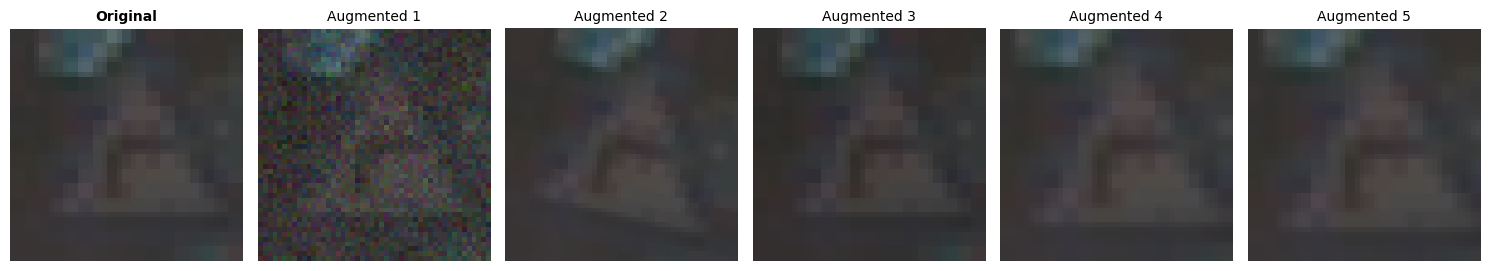

Augmentation examples saved to: ./gtrsb_dataset/augmentation_examples.png

Balancing dataset with augmentation...
Original class distribution:
Min samples: 210
Max samples: 2250
Mean samples: 911.8
Median samples: 600.0

Target samples per class: 600



Balancing classes: 100%|██████████| 43/43 [00:00<00:00, 80.14it/s] 



BALANCING COMPLETE
Original dataset size: 39209
Balanced dataset size: 44789
Images added: 5580

Generating distribution comparison...


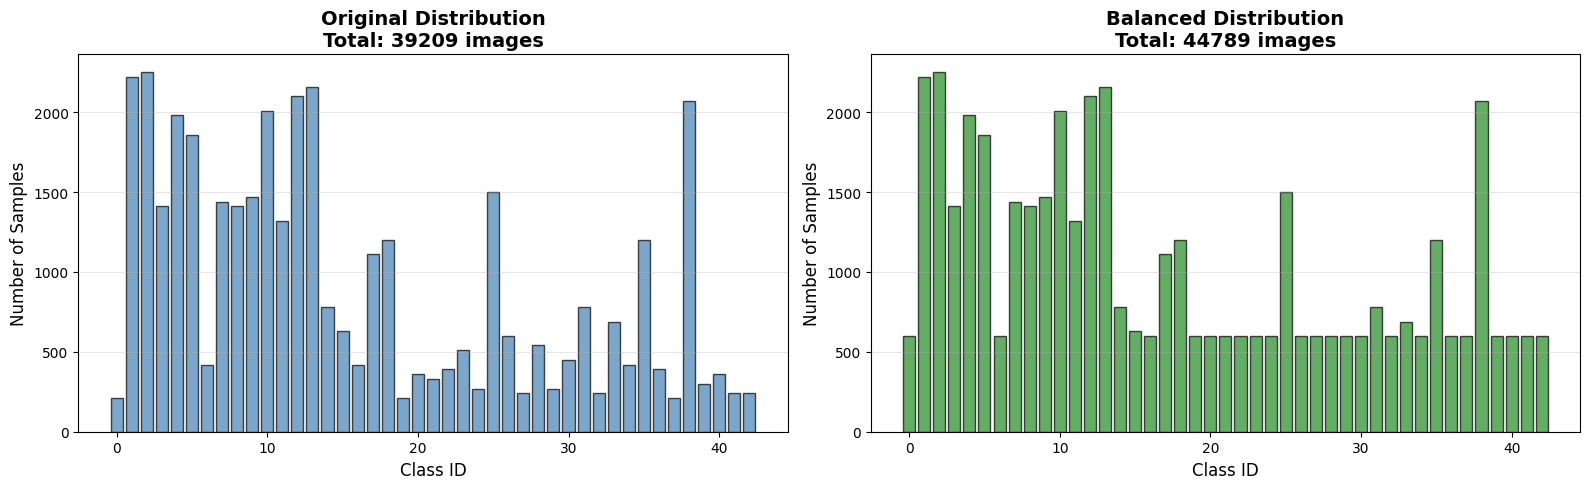


Distribution comparison saved to: ./gtrsb_dataset/distribution_comparison.png

Balanced dataset saved to: ./gtrsb_dataset/balanced_train

Final statistics:
Number of classes: 43
Min samples per class: 600
Max samples per class: 2250
Mean samples per class: 1041.6
Std samples per class: 579.5


In [4]:
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

def augment_image(image):
    """
    Apply random augmentation to an image.
    Returns augmented image.
    """
    # Randomly choose augmentation technique
    aug_type = np.random.randint(0, 5)
    
    if aug_type == 0:
        # Rotation (±15 degrees)
        angle = np.random.uniform(-15, 15)
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        augmented = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        
    elif aug_type == 1:
        # Brightness adjustment
        factor = np.random.uniform(0.7, 1.3)
        augmented = np.clip(image * factor, 0, 255).astype(np.uint8)
        
    elif aug_type == 2:
        # Gaussian noise
        noise = np.random.normal(0, 10, image.shape)
        augmented = np.clip(image + noise, 0, 255).astype(np.uint8)
        
    #elif aug_type == 4:
    #    # Horizontal flip (careful with traffic signs - some are symmetric)
    #    augmented = cv2.flip(image, 1)
        
    elif aug_type == 3:
        # Slight zoom (crop and resize)
        h, w = image.shape[:2]
        crop_percent = np.random.uniform(0.85, 0.95)
        new_h, new_w = int(h * crop_percent), int(w * crop_percent)
        y1 = (h - new_h) // 2
        x1 = (w - new_w) // 2
        cropped = image[y1:y1+new_h, x1:x1+new_w]
        augmented = cv2.resize(cropped, (w, h))
        
    else:
        # Gaussian blur
        augmented = cv2.GaussianBlur(image, (3, 3), 0)
    
    return augmented

def balance_dataset_with_augmentation(images, labels, target_samples_per_class=None, max_samples_per_class=None):
    """
    Balance dataset by augmenting underrepresented classes.
    
    Args:
        images: numpy array of images
        labels: numpy array of labels
        target_samples_per_class: target number of samples per class (default: median)
        max_samples_per_class: maximum samples per class to avoid over-augmenting
    
    Returns:
        balanced_images, balanced_labels
    """
    unique_classes = np.unique(labels)
    class_counts = {cls: np.sum(labels == cls) for cls in unique_classes}
    
    print("Original class distribution:")
    print(f"Min samples: {min(class_counts.values())}")
    print(f"Max samples: {max(class_counts.values())}")
    print(f"Mean samples: {np.mean(list(class_counts.values())):.1f}")
    print(f"Median samples: {np.median(list(class_counts.values())):.1f}\n")
    
    # Set target if not provided
    if target_samples_per_class is None:
        target_samples_per_class = int(np.median(list(class_counts.values())))
    
    if max_samples_per_class is None:
        max_samples_per_class = max(class_counts.values())
    
    # Cap target at max
    target_samples_per_class = min(target_samples_per_class, max_samples_per_class)
    
    print(f"Target samples per class: {target_samples_per_class}\n")
    
    balanced_images = []
    balanced_labels = []
    
    for cls in tqdm(unique_classes, desc="Balancing classes"):
        # Get all images for this class
        class_mask = labels == cls
        class_images = images[class_mask]
        current_count = len(class_images)
        
        # Add all original images
        balanced_images.extend(class_images)
        balanced_labels.extend([cls] * current_count)
        
        # Augment if needed
        if current_count < target_samples_per_class:
            needed = target_samples_per_class - current_count
            
            # Generate augmented images
            for _ in range(needed):
                # Pick random image from this class
                idx = np.random.randint(0, current_count)
                original = class_images[idx]
                
                # Augment it
                augmented = augment_image(original)
                
                balanced_images.append(augmented)
                balanced_labels.append(cls)
    
    return np.array(balanced_images), np.array(balanced_labels)

def plot_class_distribution_comparison(original_labels, balanced_labels, output_path):
    """
    Plot before and after class distribution.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Original distribution
    unique_orig, counts_orig = np.unique(original_labels, return_counts=True)
    ax1.bar(unique_orig, counts_orig, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Class ID', fontsize=12)
    ax1.set_ylabel('Number of Samples', fontsize=12)
    ax1.set_title(f'Original Distribution\nTotal: {len(original_labels)} images', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Balanced distribution
    unique_bal, counts_bal = np.unique(balanced_labels, return_counts=True)
    ax2.bar(unique_bal, counts_bal, color='forestgreen', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Class ID', fontsize=12)
    ax2.set_ylabel('Number of Samples', fontsize=12)
    ax2.set_title(f'Balanced Distribution\nTotal: {len(balanced_labels)} images', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nDistribution comparison saved to: {output_path}")

def visualize_augmentations(image, num_augmentations=5):
    """
    Show original image and several augmented versions.
    """
    fig, axes = plt.subplots(1, num_augmentations + 1, figsize=(15, 3))
    
    # Original
    axes[0].imshow(image)
    axes[0].set_title('Original', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Augmented versions
    for i in range(num_augmentations):
        augmented = augment_image(image)
        axes[i+1].imshow(augmented)
        axes[i+1].set_title(f'Augmented {i+1}', fontsize=10)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.savefig('./gtrsb_dataset/augmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Augmentation examples saved to: ./gtrsb_dataset/augmentation_examples.png")

# Main execution
print("="*60)
print("DATA AUGMENTATION FOR CLASS BALANCING")
print("="*60)

# Load preprocessed data
output_path = './gtrsb_dataset/cropped_train'
cropped_images = np.load(os.path.join(output_path, 'cropped_images.npy'))
labels = np.load(os.path.join(output_path, 'labels.npy'))

print(f"\nLoaded {len(cropped_images)} preprocessed images")

# Show example of augmentations
print("\nGenerating augmentation examples...")
sample_image = cropped_images[0]
visualize_augmentations(sample_image, num_augmentations=5)

# Balance the dataset
print("\nBalancing dataset with augmentation...")
balanced_images, balanced_labels = balance_dataset_with_augmentation(
    cropped_images, 
    labels,
    target_samples_per_class=600,  # Adjust this value as needed
    max_samples_per_class=750      # Cap to avoid making majority classes too large
)

print("\n" + "="*60)
print("BALANCING COMPLETE")
print("="*60)
print(f"Original dataset size: {len(cropped_images)}")
print(f"Balanced dataset size: {len(balanced_images)}")
print(f"Images added: {len(balanced_images) - len(cropped_images)}")

# Plot comparison
print("\nGenerating distribution comparison...")
plot_class_distribution_comparison(
    labels, 
    balanced_labels,
    './gtrsb_dataset/distribution_comparison.png'
)

# Save balanced dataset
balanced_output_path = './gtrsb_dataset/balanced_train'
os.makedirs(balanced_output_path, exist_ok=True)
np.save(os.path.join(balanced_output_path, 'balanced_images.npy'), balanced_images)
np.save(os.path.join(balanced_output_path, 'balanced_labels.npy'), balanced_labels)

print(f"\n{'='*60}")
print(f"Balanced dataset saved to: {balanced_output_path}")
print(f"{'='*60}")

# Final statistics
unique_classes, counts = np.unique(balanced_labels, return_counts=True)
print(f"\nFinal statistics:")
print(f"Number of classes: {len(unique_classes)}")
print(f"Min samples per class: {counts.min()}")
print(f"Max samples per class: {counts.max()}")
print(f"Mean samples per class: {counts.mean():.1f}")
print(f"Std samples per class: {counts.std():.1f}")

In [5]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import skew, kurtosis
import cv2

def extract_color_histogram(image, bins=16):
    """
    Extract color histogram features from RGB channels.
    
    Args:
        image: RGB image
        bins: number of bins per channel
    
    Returns:
        Flattened histogram features
    """
    features = []
    
    # Histogram for each RGB channel
    for i in range(3):
        hist = cv2.calcHist([image], [i], None, [bins], [0, 256])
        hist = hist.flatten() / hist.sum()  # Normalize
        features.extend(hist)
    
    return np.array(features)

def extract_color_moments(image):
    """
    Extract color moments (mean, std, skewness, kurtosis) for each channel.
    
    Returns:
        12 features (4 moments × 3 channels)
    """
    features = []
    
    for i in range(3):
        channel = image[:, :, i].flatten()
        features.append(np.mean(channel))
        features.append(np.std(channel))
        features.append(skew(channel))
        features.append(kurtosis(channel))
    
    return np.array(features)

def extract_color_features(images, labels, bins=16):
    """
    Extract color features (histograms + moments) from images.
    
    Args:
        images: Array of images
        labels: Array of labels
        bins: Number of histogram bins per channel
    
    Returns:
        DataFrame with color features and labels
    """
    print(f"Extracting color features from {len(images)} images...")
    print(f"Histogram bins per channel: {bins}")
    print(f"Total features: {bins*3 + 12} (histogram: {bins*3}, moments: 12)\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        # Extract histogram features
        hist_features = extract_color_histogram(img, bins=bins)
        
        # Extract moment features
        moment_features = extract_color_moments(img)
        
        # Combine
        features = np.concatenate([hist_features, moment_features])
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = []
    
    # Histogram column names
    for channel in ['R', 'G', 'B']:
        for bin_idx in range(bins):
            column_names.append(f'hist_{channel}_bin{bin_idx}')
    
    # Moment column names
    for channel in ['R', 'G', 'B']:
        for moment in ['mean', 'std', 'skew', 'kurt']:
            column_names.append(f'moment_{channel}_{moment}')
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"Features per image: {len(column_names)}")
    
    return df

# Load preprocessed data
output_path = './gtrsb_dataset/balanced_train'
images = np.load(os.path.join(output_path, 'balanced_images.npy'))
labels = np.load(os.path.join(output_path, 'balanced_labels.npy'))

print(f"\nLoaded {len(images)} preprocessed images")

# Extract color features
color_features_df = extract_color_features(images, labels, bins=16)

# Display results
print("\nFirst few rows:")
print(color_features_df.head())

print("\nBasic statistics:")
print(color_features_df.describe())

print("\nClass distribution:")
print(color_features_df['label'].value_counts().sort_index())

# Save to CSV
output_csv = './gtrsb_dataset/balanced_train/color_features.csv'
color_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")


Loaded 44789 preprocessed images
Extracting color features from 44789 images...
Histogram bins per channel: 16
Total features: 60 (histogram: 48, moments: 12)



Processing: 100%|██████████| 44789/44789 [01:30<00:00, 495.82it/s]



✓ Feature extraction complete!
DataFrame shape: (44789, 61)
Features per image: 60

First few rows:
   hist_R_bin0  hist_R_bin1  hist_R_bin2  hist_R_bin3  hist_R_bin4  \
0          0.0     0.000000     0.001736     0.026910     0.106337   
1          0.0     0.000000     0.001736     0.049479     0.119358   
2          0.0     0.000000     0.001736     0.039062     0.140625   
3          0.0     0.000434     0.005642     0.060330     0.109375   
4          0.0     0.000868     0.014757     0.091146     0.114583   

   hist_R_bin5  hist_R_bin6  hist_R_bin7  hist_R_bin8  hist_R_bin9  ...  \
0     0.155382     0.159288     0.119792     0.109375     0.092014  ...   
1     0.140625     0.143229     0.094618     0.102431     0.072917  ...   
2     0.117188     0.117622     0.093750     0.123698     0.092882  ...   
3     0.131076     0.129774     0.115017     0.103733     0.109375  ...   
4     0.101562     0.097222     0.115451     0.109375     0.091580  ...   

   moment_R_kurt  moment_G_

In [6]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import hog

def extract_hog_features(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2)):
    """
    Extract Histogram of Oriented Gradients (HOG) features.
    Captures edge orientations and structure.
    
    Args:
        orientations: Number of orientation bins (default: 9)
        pixels_per_cell: Cell size - LARGER = FEWER features (default: 16x16)
        cells_per_block: Cells per block (default: 2x2)
    
    Returns:
        HOG feature vector
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # HOG parameters - adjusted for fewer features
    features = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,  # Increased from (8,8) to reduce features
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True
    )
    
    return features

def extract_canny_features(image):
    """
    Extract edge features using Canny edge detection.
    
    Returns:
        Edge statistics (5 features)
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Apply Canny edge detection
    edges = cv2.Canny(gray, 50, 150)
    
    # Extract statistics from edge map
    features = [
        np.sum(edges > 0) / edges.size,  # Edge density
        np.mean(edges),                   # Mean edge intensity
        np.std(edges),                    # Std of edge intensity
        np.sum(edges > 0),                # Total edge pixels
        np.max(edges)                     # Max edge intensity
    ]
    
    return np.array(features)

def extract_edge_structure_features(images, labels, hog_params=None):
    """
    Extract edge and structure features (HOG + Canny) from images.
    
    Args:
        images: Array of images
        labels: Array of labels
        hog_params: Dict with HOG parameters (orientations, pixels_per_cell, cells_per_block)
    
    Returns:
        DataFrame with edge/structure features and labels
    """
    # Default HOG parameters for fewer features
    if hog_params is None:
        hog_params = {
            'orientations': 9,
            'pixels_per_cell': (16, 16),  # Larger cells = fewer features
            'cells_per_block': (2, 2)
        }
    
    print(f"Extracting edge and structure features from {len(images)} images...")
    print(f"HOG parameters:")
    print(f"  - Orientations: {hog_params['orientations']}")
    print(f"  - Pixels per cell: {hog_params['pixels_per_cell']}")
    print(f"  - Cells per block: {hog_params['cells_per_block']}")
    print("Features: HOG + Canny edge detection\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        # Extract HOG features
        hog_features = extract_hog_features(
            img,
            orientations=hog_params['orientations'],
            pixels_per_cell=hog_params['pixels_per_cell'],
            cells_per_block=hog_params['cells_per_block']
        )
        
        # Extract Canny edge features
        canny_features = extract_canny_features(img)
        
        # Combine
        features = np.concatenate([hog_features, canny_features])
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = []
    
    # HOG column names
    num_hog_features = len(all_features[0]) - 5  # Total minus 5 Canny features
    for i in range(num_hog_features):
        column_names.append(f'hog_{i}')
    
    # Canny column names
    canny_names = ['edge_density', 'edge_mean', 'edge_std', 'edge_count', 'edge_max']
    column_names.extend(canny_names)
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"HOG features: {num_hog_features}")
    print(f"Canny features: 5")
    print(f"Total features: {len(column_names)}")
    
    return df

# Extract edge and structure features with REDUCED HOG dimensions
# Option 1: Fewer features (~36 HOG features)
edge_structure_df = extract_edge_structure_features(
    images, 
    labels,
    hog_params={
        'orientations': 9,
        'pixels_per_cell': (24, 24),  # Larger cells = fewer features
        'cells_per_block': (2, 2)
    }
)

# If you want even fewer features, try:
# Option 2: Very few features (~9 HOG features)
# edge_structure_df = extract_edge_structure_features(
#     images, 
#     labels,
#     hog_params={
#         'orientations': 9,
#         'pixels_per_cell': (24, 24),  # Even larger cells
#         'cells_per_block': (1, 1)
#     }
# )

# Display results
print("\nFirst few rows:")
print(edge_structure_df.head())

print("\nBasic statistics (sample features):")
cols_to_show = list(edge_structure_df.columns[:5]) + list(edge_structure_df.columns[-6:])
print(edge_structure_df[cols_to_show].describe())

# Save to CSV
output_csv = './gtrsb_dataset/balanced_train/edge_structure_features.csv'
edge_structure_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

Extracting edge and structure features from 44789 images...
HOG parameters:
  - Orientations: 9
  - Pixels per cell: (24, 24)
  - Cells per block: (2, 2)
Features: HOG + Canny edge detection



Processing: 100%|██████████| 44789/44789 [00:25<00:00, 1743.90it/s]



✓ Feature extraction complete!
DataFrame shape: (44789, 42)
HOG features: 36
Canny features: 5
Total features: 41

First few rows:
      hog_0     hog_1     hog_2     hog_3     hog_4     hog_5     hog_6  \
0  0.162523  0.109170  0.117971  0.189106  0.235909  0.189451  0.096180   
1  0.235843  0.129036  0.171069  0.233003  0.244470  0.059411  0.051643   
2  0.173168  0.109151  0.177050  0.228253  0.228253  0.118993  0.090443   
3  0.201325  0.214466  0.198524  0.212696  0.216172  0.110082  0.078286   
4  0.104108  0.156413  0.173916  0.231381  0.242466  0.076782  0.050958   

      hog_7     hog_8     hog_9  ...    hog_32    hog_33    hog_34    hog_35  \
0  0.051889  0.067787  0.151933  ...  0.086085  0.073029  0.057001  0.235909   
1  0.029632  0.091746  0.115576  ...  0.112979  0.075145  0.086858  0.244470   
2  0.072637  0.085049  0.151974  ...  0.113262  0.061299  0.091884  0.228253   
3  0.072992  0.106920  0.156430  ...  0.115140  0.061342  0.081142  0.216172   
4  0.049721  0.07

In [7]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def extract_shape_features(image):
    """
    Extract shape features using Hu Moments and basic shape descriptors.
    
    Hu Moments are invariant to translation, rotation, and scale.
    Perfect for capturing the overall shape of traffic signs.
    
    Returns:
        Shape features (7 Hu moments + additional shape descriptors)
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Apply binary threshold to get shape silhouette
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Calculate image moments
    moments = cv2.moments(binary)
    
    # Calculate Hu Moments (7 features)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Log transform for better scale (Hu moments can be very small/large)
    hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    
    # Additional shape descriptors
    additional_features = []
    
    # Contour-based features
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        # Get the largest contour (assumed to be the traffic sign)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Area and perimeter
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)
        
        # Circularity (how circular is the shape)
        circularity = 4 * np.pi * area / (perimeter ** 2 + 1e-10)
        
        # Aspect ratio from bounding rectangle
        if len(largest_contour) >= 5:
            ellipse = cv2.fitEllipse(largest_contour)
            major_axis = max(ellipse[1])
            minor_axis = min(ellipse[1])
            aspect_ratio = major_axis / (minor_axis + 1e-10)
        else:
            aspect_ratio = 1.0
        
        # Extent (ratio of contour area to bounding box area)
        x, y, w, h = cv2.boundingRect(largest_contour)
        rect_area = w * h
        extent = area / (rect_area + 1e-10)
        
        # Solidity (ratio of contour area to convex hull area)
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / (hull_area + 1e-10)
        
        additional_features = [
            area / (gray.shape[0] * gray.shape[1]),  # Normalized area
            perimeter / (2 * (gray.shape[0] + gray.shape[1])),  # Normalized perimeter
            circularity,
            aspect_ratio,
            extent,
            solidity
        ]
    else:
        # If no contours found, use default values
        additional_features = [0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
    
    # Combine all shape features
    shape_features = np.concatenate([hu_moments, additional_features])
    
    return shape_features

def extract_all_shape_features(images, labels):
    """
    Extract shape features from all images.
    
    Args:
        images: Array of images
        labels: Array of labels
    
    Returns:
        DataFrame with shape features and labels
    """
    print(f"Extracting shape features from {len(images)} images...")
    print("Method: Hu Moments + Shape Descriptors")
    print("Features: 7 Hu moments + 6 shape descriptors = 13 total\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        features = extract_shape_features(img)
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = [
        'hu_moment_1', 'hu_moment_2', 'hu_moment_3', 'hu_moment_4',
        'hu_moment_5', 'hu_moment_6', 'hu_moment_7',
        'normalized_area', 'normalized_perimeter', 'circularity',
        'aspect_ratio', 'extent', 'solidity'
    ]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"Total shape features: {len(column_names)}")
    
    return df

# Extract shape features
shape_features_df = extract_all_shape_features(images, labels)

# Display results
print("\nFirst few rows:")
print(shape_features_df.head())

print("\nBasic statistics:")
print(shape_features_df.describe())

print("\nFeature descriptions:")
print("  • Hu moments (1-7): Rotation, scale, translation invariant shape descriptors")
print("  • Normalized area: Area relative to image size")
print("  • Normalized perimeter: Perimeter relative to image size")
print("  • Circularity: How circular the shape is (1.0 = perfect circle)")
print("  • Aspect ratio: Ratio of major to minor axis")
print("  • Extent: Ratio of shape area to bounding box area")
print("  • Solidity: Ratio of shape area to convex hull area")

# Save to CSV
output_csv = './gtrsb_dataset/balanced_train/shape_features.csv'
shape_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

Extracting shape features from 44789 images...
Method: Hu Moments + Shape Descriptors
Features: 7 Hu moments + 6 shape descriptors = 13 total



Processing: 100%|██████████| 44789/44789 [00:03<00:00, 14830.59it/s]



✓ Feature extraction complete!
DataFrame shape: (44789, 14)
Total shape features: 13

First few rows:
   hu_moment_1  hu_moment_2  hu_moment_3  hu_moment_4  hu_moment_5  \
0     3.001300     7.132336     9.827191     9.907501         10.0   
1     2.904861     7.549944     9.961708     9.611435        -10.0   
2     2.951018     7.471890     9.977023     9.742715        -10.0   
3     2.924417     7.671095     9.906467     9.770518        -10.0   
4     2.952218     7.806859     9.925933     9.848939        -10.0   

   hu_moment_6  hu_moment_7  normalized_area  normalized_perimeter  \
0     9.999975         10.0         0.272135              0.793888   
1     9.999895        -10.0         0.290799              0.557879   
2     9.999941        -10.0         0.317057              0.593967   
3     9.999958        -10.0         0.303819              0.581239   
4     9.999978        -10.0         0.366753              0.645527   

   circularity  aspect_ratio    extent  solidity  label

In [8]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.feature import local_binary_pattern

def extract_lbp_features(image, radius=2, n_points=None, method='uniform'):
    """
    Extract Local Binary Pattern (LBP) features for texture analysis.
    
    LBP is excellent for capturing local texture patterns like:
    - Arrows on signs
    - Numbers and text
    - Directional patterns
    - Surface texture details
    
    Args:
        radius: Radius of circle (default: 2)
        n_points: Number of points on circle (default: 8*radius)
        method: 'uniform' for rotation-invariant uniform patterns
    
    Returns:
        LBP histogram features
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Set number of points if not specified
    if n_points is None:
        n_points = 8 * radius
    
    # Compute LBP
    lbp = local_binary_pattern(gray, n_points, radius, method=method)
    
    # Calculate histogram
    if method == 'uniform':
        # Uniform patterns have n_points + 2 bins
        n_bins = n_points + 2
    else:
        # Non-uniform patterns have 2^n_points bins
        n_bins = int(lbp.max() + 1)
    
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    
    # Normalize histogram
    hist = hist.astype(float) / (hist.sum() + 1e-10)
    
    return hist

def extract_all_texture_features(images, labels, radius=2):
    """
    Extract LBP texture features from all images.
    
    Args:
        images: Array of images
        labels: Array of labels
        radius: LBP radius (1=small details, 2=medium, 3=larger patterns)
    
    Returns:
        DataFrame with LBP texture features and labels
    """
    n_points = 8 * radius
    n_bins = n_points + 2  # For uniform LBP
    
    print(f"Extracting texture features from {len(images)} images...")
    print(f"Method: Local Binary Patterns (LBP)")
    print(f"Parameters:")
    print(f"  - Radius: {radius}")
    print(f"  - Points: {n_points}")
    print(f"  - Method: uniform (rotation invariant)")
    print(f"  - Features: {n_bins} histogram bins\n")
    
    all_features = []
    
    for img in tqdm(images, desc="Processing"):
        features = extract_lbp_features(img, radius=radius, n_points=n_points, method='uniform')
        all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    # Generate column names
    column_names = [f'lbp_bin_{i}' for i in range(n_bins)]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    print(f"\n✓ Feature extraction complete!")
    print(f"DataFrame shape: {df.shape}")
    print(f"Total LBP features: {len(column_names)}")
    
    return df

# Extract LBP texture features
# radius=2 is a good balance (18 features)
# radius=1 gives 10 features (captures fine details)
# radius=3 gives 26 features (captures larger patterns)
texture_features_df = extract_all_texture_features(images, labels, radius=2)

# Display results
print("\nFirst few rows:")
print(texture_features_df.head())

print("\nBasic statistics:")
print(texture_features_df.describe())

print("\nWhat LBP captures:")
print("  • Local texture patterns (arrows, symbols, numbers)")
print("  • Edge orientations at local scale")
print("  • Rotation-invariant patterns")
print("  • Surface texture details")

# Save to CSV
output_csv = './gtrsb_dataset/balanced_train/texture_features.csv'
texture_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

Extracting texture features from 44789 images...
Method: Local Binary Patterns (LBP)
Parameters:
  - Radius: 2
  - Points: 16
  - Method: uniform (rotation invariant)
  - Features: 18 histogram bins



Processing: 100%|██████████| 44789/44789 [00:23<00:00, 1923.88it/s]



✓ Feature extraction complete!
DataFrame shape: (44789, 19)
Total LBP features: 18

First few rows:
   lbp_bin_0  lbp_bin_1  lbp_bin_2  lbp_bin_3  lbp_bin_4  lbp_bin_5  \
0   0.046007   0.008681   0.084635   0.037326   0.035590   0.044705   
1   0.048611   0.011285   0.058160   0.043403   0.037326   0.054253   
2   0.049479   0.009983   0.068576   0.045573   0.035590   0.044705   
3   0.046441   0.019531   0.057292   0.046875   0.036458   0.046007   
4   0.047309   0.008247   0.064670   0.047743   0.028646   0.048177   

   lbp_bin_6  lbp_bin_7  lbp_bin_8  lbp_bin_9  lbp_bin_10  lbp_bin_11  \
0   0.064670   0.099392   0.111545   0.110677    0.046007    0.032986   
1   0.064236   0.114149   0.094618   0.098524    0.041233    0.032118   
2   0.066406   0.111545   0.090278   0.104167    0.049913    0.032118   
3   0.063802   0.119358   0.087240   0.105035    0.042101    0.027344   
4   0.064670   0.123698   0.112413   0.122830    0.042101    0.025174   

   lbp_bin_12  lbp_bin_13  lbp_bi

In [9]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

def extract_learned_features_resnet(images, labels, model_name='resnet18', layer='avgpool'):
    """
    Extract learned features from a pre-trained ResNet model.
    
    Args:
        images: Array of images (RGB, numpy arrays)
        labels: Array of labels
        model_name: 'resnet18', 'resnet34', 'resnet50' (default: resnet18 for speed)
        layer: Which layer to extract from ('avgpool' recommended)
    
    Returns:
        DataFrame with learned features and labels
    """
    print(f"Extracting learned features from {len(images)} images...")
    print(f"Model: {model_name}")
    print(f"Layer: {layer}\n")
    
    # Load pre-trained model
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
        feature_dim = 512
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=True)
        feature_dim = 512
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
        feature_dim = 2048
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Set model to evaluation mode
    model.eval()
    
    # Remove the final classification layer to get features
    if layer == 'avgpool':
        # Extract from avgpool layer (before final FC)
        model = torch.nn.Sequential(*list(model.children())[:-1])
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"Using device: {device}")
    
    # Define preprocessing transform (ImageNet normalization)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    all_features = []
    
    # Extract features
    with torch.no_grad():
        for img in tqdm(images, desc="Extracting features"):
            # Convert numpy array to PIL Image
            pil_img = Image.fromarray(img.astype('uint8'))
            
            # Apply transforms
            img_tensor = transform(pil_img).unsqueeze(0)  # Add batch dimension
            img_tensor = img_tensor.to(device)
            
            # Extract features
            features = model(img_tensor)
            features = features.squeeze().cpu().numpy()
            
            # Flatten if needed
            if len(features.shape) > 1:
                features = features.flatten()
            
            all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    print(f"\n✓ Feature extraction complete!")
    print(f"Feature matrix shape: {feature_matrix.shape}")
    print(f"Features per image: {feature_matrix.shape[1]}")
    
    # Generate column names
    column_names = [f'{model_name}_feature_{i}' for i in range(feature_matrix.shape[1])]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    return df

def extract_learned_features_mobilenet(images, labels):
    """
    Extract learned features from MobileNetV2 (lighter and faster alternative).
    
    Args:
        images: Array of images (RGB, numpy arrays)
        labels: Array of labels
    
    Returns:
        DataFrame with learned features and labels
    """
    print(f"Extracting learned features from {len(images)} images...")
    print(f"Model: MobileNetV2 (lightweight)\n")
    
    # Load pre-trained MobileNetV2
    model = models.mobilenet_v2(pretrained=True)
    model.eval()
    
    # Remove classifier to get features (1280 features)
    model.classifier = torch.nn.Identity()
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"Using device: {device}")
    
    # Define preprocessing
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    all_features = []
    
    # Extract features
    with torch.no_grad():
        for img in tqdm(images, desc="Extracting features"):
            pil_img = Image.fromarray(img.astype('uint8'))
            img_tensor = transform(pil_img).unsqueeze(0)
            img_tensor = img_tensor.to(device)
            
            features = model(img_tensor)
            features = features.squeeze().cpu().numpy()
            
            all_features.append(features)
    
    # Convert to numpy array
    feature_matrix = np.array(all_features)
    
    print(f"\n✓ Feature extraction complete!")
    print(f"Feature matrix shape: {feature_matrix.shape}")
    print(f"Features per image: {feature_matrix.shape[1]}")
    
    # Generate column names
    column_names = [f'mobilenet_feature_{i}' for i in range(feature_matrix.shape[1])]
    
    # Create DataFrame
    df = pd.DataFrame(feature_matrix, columns=column_names)
    df['label'] = labels
    
    return df

# Choose which model to use:

# Option 1: ResNet18 (512 features, good balance)
print("="*70)
print("EXTRACTING LEARNED FEATURES - ResNet18")
print("="*70)
learned_features_df = extract_learned_features_resnet(
    images, 
    labels, 
    model_name='resnet18'
)

# Option 2: MobileNetV2 (1280 features, faster and lighter)
# print("="*70)
# print("EXTRACTING LEARNED FEATURES - MobileNetV2")
# print("="*70)
# learned_features_df = extract_learned_features_mobilenet(images, labels)

# Option 3: ResNet50 (2048 features, more powerful but slower)
# learned_features_df = extract_learned_features_resnet(
#     images, 
#     labels, 
#     model_name='resnet50'
# )

# Display results
print("\nFirst few rows:")
print(learned_features_df.head())

print("\nBasic statistics (first 5 features):")
print(learned_features_df.iloc[:, :5].describe())

print("\nClass distribution:")
print(learned_features_df['label'].value_counts().sort_index())

# Save to CSV
output_csv = './gtrsb_dataset/balanced_train/learned_features.csv'
learned_features_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved to: {output_csv}")

print("\n" + "="*70)
print("FEATURE EXTRACTION SUMMARY")
print("="*70)
print(f"Learned features: {learned_features_df.shape[1] - 1}")
print(f"Total samples: {learned_features_df.shape[0]}")
print("\nYou now have:")
print("  1. Handcrafted features (~132 features)")
print("  2. Learned features (512/1280/2048 features)")
print("\nReady to train and compare BDT models!")

C:\Users\roger\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\roger\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EXTRACTING LEARNED FEATURES - ResNet18
Extracting learned features from 44789 images...
Model: resnet18
Layer: avgpool

Using device: cpu


Extracting features: 100%|██████████| 44789/44789 [24:01<00:00, 31.07it/s]



✓ Feature extraction complete!
Feature matrix shape: (44789, 512)
Features per image: 512

First few rows:
   resnet18_feature_0  resnet18_feature_1  resnet18_feature_2  \
0            0.268340            1.939095            2.655198   
1            0.971514            2.818756            2.389275   
2            0.361018            1.944429            3.379535   
3            0.287513            1.524193            3.799093   
4            1.416662            1.473885            3.043778   

   resnet18_feature_3  resnet18_feature_4  resnet18_feature_5  \
0            1.634913            0.480580            0.000000   
1            0.873647            0.570876            0.025936   
2            1.158367            0.156516            0.002880   
3            1.059730            0.090630            0.655060   
4            1.410396            0.407065            0.054045   

   resnet18_feature_6  resnet18_feature_7  resnet18_feature_8  \
0            0.123653            1.258908    